In [1]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from bresenham import bresenham

In [2]:
class SelectLine:

    def __init__(self, img_path, win_name):
        self.img = cv2.imread(img_path)
        self.cur_img = self.img.copy()
        self.prev_img = self.img.copy()
        self.win_name = win_name
        self.line_points = []
        self.points = []
        self.point_num = 0
        

    def select_line_event(self, event, x, y, flags, param):
        
        if event == cv2.EVENT_LBUTTONDOWN:
            
    
            if self.point_num < 2:
                
                if self.point_num == 0:
                    cv2.circle(self.cur_img, (x, y), 2, (255, 255, 255), -1)
                    cv2.circle(self.prev_img, (x, y), 2, (255, 255, 255), -1)
                    
                elif self.point_num == 1:
                    cv2.line(self.cur_img, self.points[0], (x, y), (255, 255, 255), 1)
                    
                    cv2.circle(self.cur_img, (x, y), 2, (255, 255, 255), -1)
                    
                self.point_num += 1
                self.points.append((x,y))
                
            print(f'{self.point_num}: {self.points}')


    def get_end_points(self):
        self.cur_img = self.img.copy()
        self.prev_img = self.img.copy()
        self.points = []
        self.point_num = 0
        
        cv2.namedWindow(self.win_name)
        cv2.setMouseCallback(self.win_name, self.select_line_event)

        while True:
            cv2.imshow(self.win_name, self.cur_img)
            
            key = cv2.waitKey(1) & 0xFF
            if key in [27, 13]:
                break
            elif key == 8:
                self.cur_img = self.prev_img
                self.prev_img = self.img.copy()
                if self.point_num > 0:
                    self.points.pop()
                    self.point_num -= 1
                    
                print(f'{self.point_num}: {self.points}')

        cv2.destroyAllWindows()

        return self.points

    def get_line_points(self):

        if self.point_num < 2:
            self.get_end_points()
            
        (x1, y1), (x2, y2) = self.points
        self.line_points = list(bresenham(x1, y1, x2, y2))
        
        return self.line_points

    def select_line_from_img(self):

        if not self.line_points:
            self.get_line_points()
            
        x = [point[0] for point in self.line_points]
        y = [point[1] for point in self.line_points]

        out = self.img[y, x]
        return out

In [3]:
%load_ext autoreload
%autoreload 2

1: [(195, 508)]
2: [(195, 508), (247, 505)]


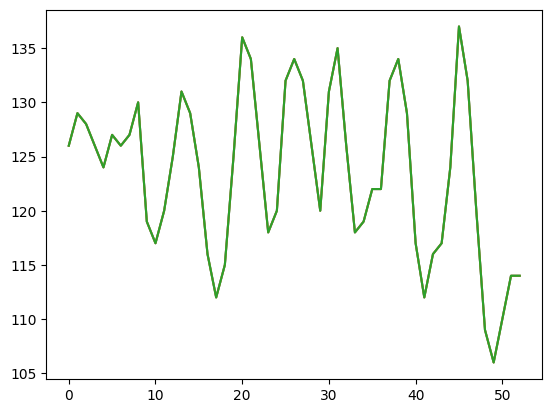

In [5]:
import generate_areas as ga
import matplotlib.pyplot as plt

select = ga.SelectLine('./data/2026.03.03/run-3/38.jpg', 'image')
out = select.select_line_from_img()

plt.figure()
plt.plot(out)
plt.show()

In [66]:
arr = np.array([[0.86427]*250]*100, dtype=np.float64)
arr.nbytes

200000

In [53]:
print([point[0] for point in points])

[212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250]


In [63]:
list_example = [[1,2,3],[4,5,6],[7,8,9]]
json_path = 'json.txt'

with open(json_path, 'w') as f:
    json.dump(list_example, f)

with open(json_path,'r') as f:
        imgs = json.load(f)

print(imgs)

[[1, 2, 3], [4, 5, 6], [7, 8, 9]]


In [65]:
a = [[0]*10]*2
a

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]